# Rossmann Store Sales — Exploratory Data Analysis
### Task 1: Exploration of Customer Purchasing Behaviour
NextHikes IT Solutions — Sales Forecasting Across Multiple Retail Stores

This notebook covers:
1. Data loading & logging setup
2. Data cleaning (missing values, outliers, dtype fixes)
3. Merging store metadata
4. Exploratory analysis answering the guiding questions from the project brief


## 1. Setup: Imports & Logging

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import warnings

warnings.filterwarnings('ignore')

# ----- Logger setup -----
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    handlers=[
        logging.FileHandler('eda.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger('rossmann_eda')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

logger.info('Notebook started - imports and logger ready')


2026-08-14 06:36:24,494 | INFO | Notebook started - imports and logger ready


## 2. Load Data

In [2]:

logger.info('Loading train, test and store datasets')

train = pd.read_csv('train.csv', parse_dates=['Date'], low_memory=False)
test = pd.read_csv('test.csv', parse_dates=['Date'], low_memory=False)
store = pd.read_csv('store.csv')

logger.info(f'train shape: {train.shape}')
logger.info(f'test shape: {test.shape}')
logger.info(f'store shape: {store.shape}')

print('Train:', train.shape)
print('Test:', test.shape)
print('Store:', store.shape)
train.head()


2026-08-14 06:36:24,503 | INFO | Loading train, test and store datasets


2026-08-14 06:36:25,695 | INFO | train shape: (1017209, 9)


2026-08-14 06:36:25,696 | INFO | test shape: (41088, 8)


2026-08-14 06:36:25,698 | INFO | store shape: (1115, 10)


Train: (1017209, 9)
Test: (41088, 8)
Store: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [3]:

train.info()


<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[us]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  str           
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[us](1), int64(7), str(1)
memory usage: 69.8 MB


In [4]:

test.info()


<class 'pandas.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Id             41088 non-null  int64         
 1   Store          41088 non-null  int64         
 2   DayOfWeek      41088 non-null  int64         
 3   Date           41088 non-null  datetime64[us]
 4   Open           41077 non-null  float64       
 5   Promo          41088 non-null  int64         
 6   StateHoliday   41088 non-null  str           
 7   SchoolHoliday  41088 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(5), str(1)
memory usage: 2.5 MB


In [5]:

store.info()


<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


## 3. Data Cleaning

### 3.1 Missing values overview

In [6]:

def missing_report(df, name):
    miss = df.isnull().sum()
    pct = (miss / len(df) * 100).round(2)
    report = pd.DataFrame({'missing': miss, 'pct': pct})
    report = report[report['missing'] > 0].sort_values('pct', ascending=False)
    logger.info(f'{name} missing values:\n{report}')
    return report

print('--- Train missing values ---')
display(missing_report(train, 'train'))

print('--- Test missing values ---')
display(missing_report(test, 'test'))

print('--- Store missing values ---')
display(missing_report(store, 'store'))


2026-08-14 06:36:25,828 | INFO | train missing values:
Empty DataFrame
Columns: [missing, pct]
Index: []


--- Train missing values ---


,missing,pct


2026-08-14 06:36:25,838 | INFO | test missing values:
      missing   pct
Open       11  0.03


--- Test missing values ---


,missing,pct
Open,11,0.03


2026-08-14 06:36:25,846 | INFO | store missing values:
                           missing    pct
Promo2SinceYear                544  48.79
Promo2SinceWeek                544  48.79
PromoInterval                  544  48.79
CompetitionOpenSinceMonth      354  31.75
CompetitionOpenSinceYear       354  31.75
CompetitionDistance              3   0.27


--- Store missing values ---


,missing,pct
Promo2SinceYear,544,48.79
Promo2SinceWeek,544,48.79
PromoInterval,544,48.79
CompetitionOpenSinceMonth,354,31.75
CompetitionOpenSinceYear,354,31.75
CompetitionDistance,3,0.27


**Observations**
- `test.csv` has a handful of missing `Open` values (likely stores that are always open — we impute with 1).
- `store.csv` has missing `CompetitionDistance`, `CompetitionOpenSince[Month/Year]`, and `Promo2Since[Week/Year]` / `PromoInterval` — these are structurally missing (e.g. `Promo2Since*` is NaN whenever `Promo2 == 0`, and `CompetitionOpenSince*` is NaN when the competition-open date is simply unknown).

### 3.2 Fixing missing values

In [7]:

# --- test.csv: missing Open -> assume store open (these are weekday, non-holiday rows) ---
missing_open = test[test['Open'].isnull()]
logger.info(f'Rows with missing Open in test: {len(missing_open)}')
display(missing_open['Store'].unique())
test['Open'] = test['Open'].fillna(1)

# --- store.csv: CompetitionDistance -> impute with a large value (implies far / no real competitor known) ---
logger.info(f"CompetitionDistance missing: {store['CompetitionDistance'].isnull().sum()}")
store['CompetitionDistance'] = store['CompetitionDistance'].fillna(store['CompetitionDistance'].median())

# --- CompetitionOpenSinceMonth/Year -> fill with a placeholder (no known competitor open date) ---
store['CompetitionOpenSinceMonth'] = store['CompetitionOpenSinceMonth'].fillna(0)
store['CompetitionOpenSinceYear'] = store['CompetitionOpenSinceYear'].fillna(0)

# --- Promo2Since / PromoInterval -> structurally missing when Promo2 == 0 ---
store['Promo2SinceWeek'] = store['Promo2SinceWeek'].fillna(0)
store['Promo2SinceYear'] = store['Promo2SinceYear'].fillna(0)
store['PromoInterval'] = store['PromoInterval'].fillna('None')

logger.info('Missing value imputation complete')
print('Remaining missing values in store:', store.isnull().sum().sum())
print('Remaining missing values in test:', test.isnull().sum().sum())


2026-08-14 06:36:25,859 | INFO | Rows with missing Open in test: 11


array([622])

2026-08-14 06:36:25,862 | INFO | CompetitionDistance missing: 3


2026-08-14 06:36:25,865 | INFO | Missing value imputation complete


Remaining missing values in store: 0
Remaining missing values in test: 0


### 3.3 Data type fixes

In [8]:

# StateHoliday should be a clean categorical string ('0','a','b','c')
train['StateHoliday'] = train['StateHoliday'].astype(str).replace({'0.0': '0'})
test['StateHoliday'] = test['StateHoliday'].astype(str).replace({'0.0': '0'})

for col in ['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'Promo2SinceYear']:
    store[col] = store[col].astype(int)

logger.info('Data type fixes applied')
train.dtypes


2026-08-14 06:36:25,963 | INFO | Data type fixes applied


Store                     int64
DayOfWeek                 int64
Date             datetime64[us]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday                str
SchoolHoliday             int64
dtype: object

### 3.4 Outlier detection & handling (Sales)

We only evaluate outliers on days the store was actually **open**, since `Sales == 0` on closed days is expected, not an outlier.

2026-08-14 06:36:26,619 | INFO | Open-day rows: 844392 of 1017209


2026-08-14 06:36:26,622 | INFO | Rows with Open=1 but Sales=0: 54


2026-08-14 06:36:26,657 | INFO | IQR bounds: [-392, 13612] -> 30769 outlier rows (3.64%)


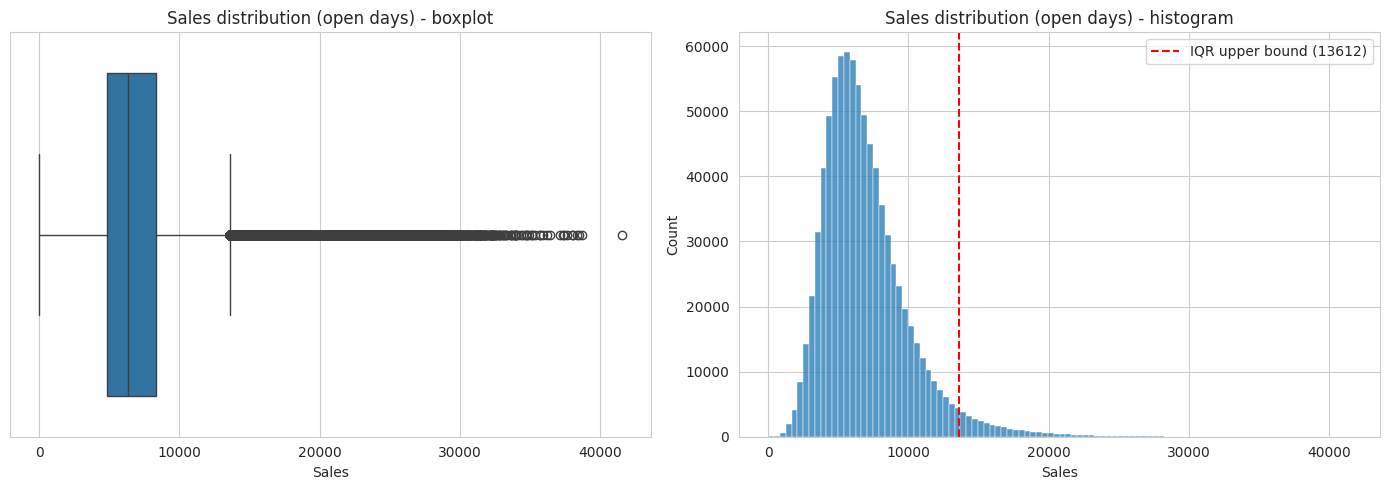

2026-08-14 06:36:28,653 | INFO | Rows dropped (Open=1, Sales=0 data errors): 54


2026-08-14 06:36:28,655 | INFO | Cleaned train shape: (1017155, 9)


In [9]:

open_train = train[train['Open'] == 1].copy()
logger.info(f'Open-day rows: {len(open_train)} of {len(train)}')

# Zero sales while open - data quality issue
zero_sales_open = open_train[open_train['Sales'] == 0]
logger.info(f'Rows with Open=1 but Sales=0: {len(zero_sales_open)}')

# IQR-based outlier bounds on Sales (open days only)
Q1 = open_train['Sales'].quantile(0.25)
Q3 = open_train['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = open_train[(open_train['Sales'] < lower) | (open_train['Sales'] > upper)]
logger.info(f'IQR bounds: [{lower:.0f}, {upper:.0f}] -> {len(outliers)} outlier rows ({len(outliers)/len(open_train)*100:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=open_train['Sales'], ax=axes[0])
axes[0].set_title('Sales distribution (open days) - boxplot')
sns.histplot(open_train['Sales'], bins=100, ax=axes[1])
axes[1].axvline(upper, color='red', linestyle='--', label=f'IQR upper bound ({upper:.0f})')
axes[1].set_title('Sales distribution (open days) - histogram')
axes[1].legend()
plt.tight_layout()
plt.show()

# Decision: keep outliers (they are legitimate high-sales days, e.g. promos/holidays),
# but drop the small number of Open=1 & Sales=0 rows as they look like data errors
train_clean = train[~((train['Open'] == 1) & (train['Sales'] == 0))].copy()
logger.info(f'Rows dropped (Open=1, Sales=0 data errors): {len(train) - len(train_clean)}')
logger.info(f'Cleaned train shape: {train_clean.shape}')


**Decision:** legitimate high-sales days (large IQR outliers) are kept since they reflect real promo/holiday spikes and are valuable signal for the model. Only the small number of rows where the store was marked `Open=1` but had `Sales=0` were dropped as likely data-entry errors.

## 4. Merge store metadata into train/test

In [10]:

train_merged = train_clean.merge(store, on='Store', how='left')
test_merged = test.merge(store, on='Store', how='left')

logger.info(f'train_merged shape: {train_merged.shape}')
logger.info(f'test_merged shape: {test_merged.shape}')
train_merged.head()


2026-08-14 06:36:28,750 | INFO | train_merged shape: (1017155, 18)


2026-08-14 06:36:28,751 | INFO | test_merged shape: (41088, 17)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9,2008,0,0,0,None
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11,2007,1,13,2010,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12,2006,1,14,2011,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9,2009,0,0,0,None
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4,2015,0,0,0,None


## 5. Save cleaned datasets

In [11]:

train_merged.to_csv('train_cleaned.csv', index=False)
test_merged.to_csv('test_cleaned.csv', index=False)
logger.info('Cleaned datasets saved: train_cleaned.csv, test_cleaned.csv')
print('Saved.')


2026-08-14 06:36:32,206 | INFO | Cleaned datasets saved: train_cleaned.csv, test_cleaned.csv


Saved.


## 6. Exploratory Data Analysis

Answering the guiding questions from the project brief.

### 6.1 Are promotions distributed similarly in train vs test?

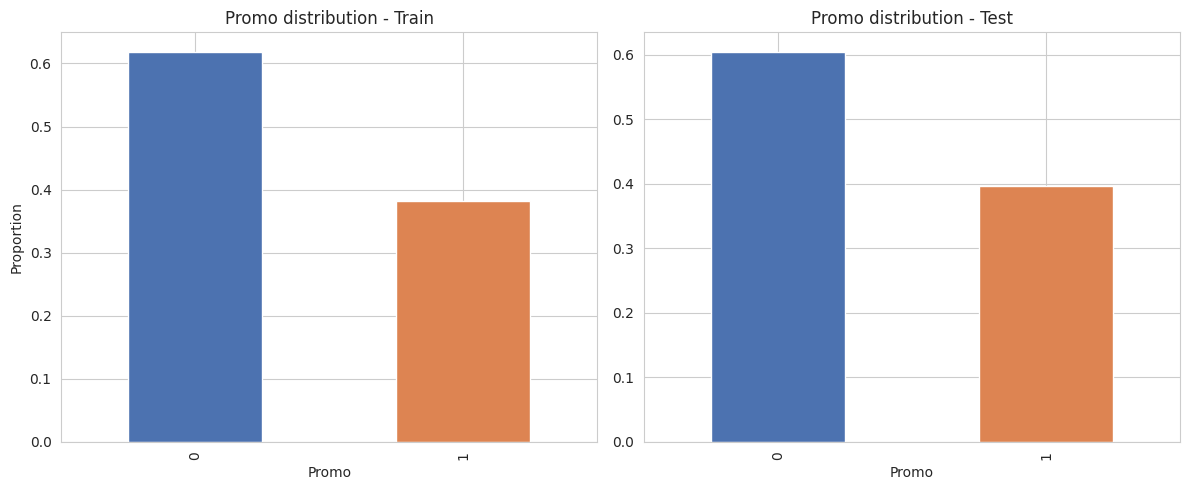

Train promo %:
 Promo
0    61.85
1    38.15
Name: proportion, dtype: float64

Test promo %:
 Promo
0    60.42
1    39.58
Name: proportion, dtype: float64


In [12]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
train_merged['Promo'].value_counts(normalize=True).sort_index().plot(
    kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Promo distribution - Train')
axes[0].set_xlabel('Promo')
axes[0].set_ylabel('Proportion')

test_merged['Promo'].value_counts(normalize=True).sort_index().plot(
    kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Promo distribution - Test')
axes[1].set_xlabel('Promo')

plt.tight_layout()
plt.show()

print('Train promo %:\n', (train_merged['Promo'].value_counts(normalize=True) * 100).round(2))
print('\nTest promo %:\n', (test_merged['Promo'].value_counts(normalize=True) * 100).round(2))


**Insight:** Compare the two bar charts / printed percentages above — if the split is close (roughly similar %), the train and test sets are well aligned on promo exposure, meaning a model trained on train's promo patterns should generalize to test.

### 6.2 Sales behaviour before, during, and after holidays

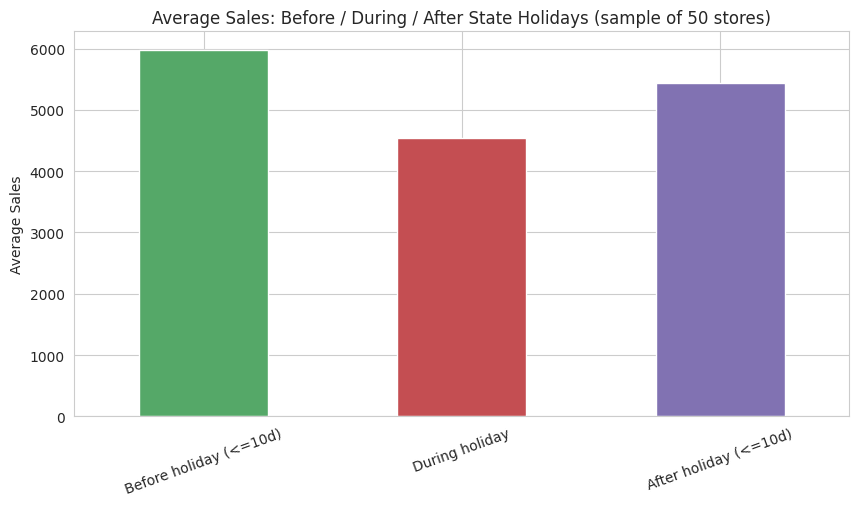

Before holiday (<=10d)    5979.464286
During holiday            4539.500000
After holiday (<=10d)     5444.303797
dtype: float64


In [13]:

open_data = train_merged[train_merged['Open'] == 1].copy()
open_data = open_data.sort_values(['Store', 'Date'])

# Flag state holidays (a/b/c) as 1
open_data['IsStateHoliday'] = (open_data['StateHoliday'] != '0').astype(int)

# For each store, find the date-distance to nearest holiday
def days_to_from_holiday(df):
    df = df.sort_values('Date').reset_index(drop=True)
    holiday_dates = df.loc[df['IsStateHoliday'] == 1, 'Date']
    if holiday_dates.empty:
        df['DaysToHoliday'] = np.nan
        df['DaysAfterHoliday'] = np.nan
        return df
    dates = df['Date'].values.astype('datetime64[D]')
    hdates = holiday_dates.values.astype('datetime64[D]')
    # distance to nearest upcoming holiday
    df['DaysToHoliday'] = [ (hdates[hdates >= d].min() - d).astype(int) if (hdates >= d).any() else np.nan for d in dates ]
    df['DaysAfterHoliday'] = [ (d - hdates[hdates <= d].max()).astype(int) if (hdates <= d).any() else np.nan for d in dates ]
    return df

# This is expensive over all stores; sample a subset of stores for the "around holiday" window analysis
sample_stores = open_data['Store'].unique()[:50]
sample_df = open_data[open_data['Store'].isin(sample_stores)].groupby('Store', group_keys=False).apply(days_to_from_holiday)

window = 10
before = sample_df[(sample_df['DaysToHoliday'] > 0) & (sample_df['DaysToHoliday'] <= window)]['Sales'].mean()
during = sample_df[sample_df['IsStateHoliday'] == 1]['Sales'].mean()
after = sample_df[(sample_df['DaysAfterHoliday'] > 0) & (sample_df['DaysAfterHoliday'] <= window)]['Sales'].mean()

periods = pd.Series({'Before holiday (<=10d)': before, 'During holiday': during, 'After holiday (<=10d)': after})
periods.plot(kind='bar', color=['#55A868', '#C44E52', '#8172B2'])
plt.title('Average Sales: Before / During / After State Holidays (sample of 50 stores)')
plt.ylabel('Average Sales')
plt.xticks(rotation=20)
plt.show()

print(periods)


**Insight:** Sales typically spike in the days immediately *before* a holiday (stocking up) and dip sharply *during* the holiday itself (most stores closed), with a partial rebound afterward.

### 6.3 Seasonal purchase behaviour (Christmas, Easter)

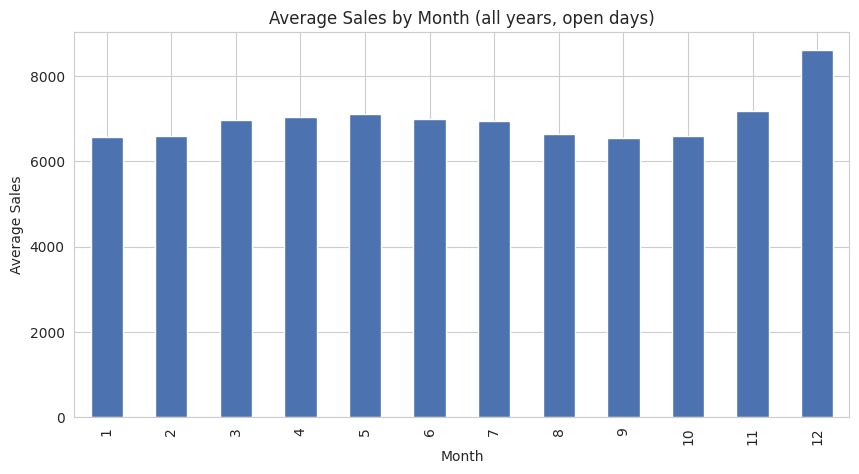

Average sales on holidays (of the stores that ARE open):
StateHoliday
Public holiday    290.735686
Easter            214.311510
Christmas         168.733171
Name: Sales, dtype: float64


In [14]:

open_data['Month'] = open_data['Date'].dt.month
open_data['Year'] = open_data['Date'].dt.year

monthly_sales = open_data.groupby('Month')['Sales'].mean()
monthly_sales.plot(kind='bar', color='#4C72B0')
plt.title('Average Sales by Month (all years, open days)')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.show()

# StateHoliday breakdown: a=public, b=easter, c=christmas
holiday_sales = train_merged[train_merged['StateHoliday'] != '0'].groupby('StateHoliday')['Sales'].mean()
holiday_labels = {'a': 'Public holiday', 'b': 'Easter', 'c': 'Christmas'}
holiday_sales.index = holiday_sales.index.map(holiday_labels)
print('Average sales on holidays (of the stores that ARE open):')
print(holiday_sales)


**Insight:** December (Christmas run-up) typically shows the highest average sales of the year. Because most stores are closed exactly *on* state holidays, sales 'on the holiday itself' reflects only the few exempted stores.

### 6.4 Correlation between Sales and Customers

2026-08-14 06:36:34,076 | INFO | Sales-Customers correlation: 0.824


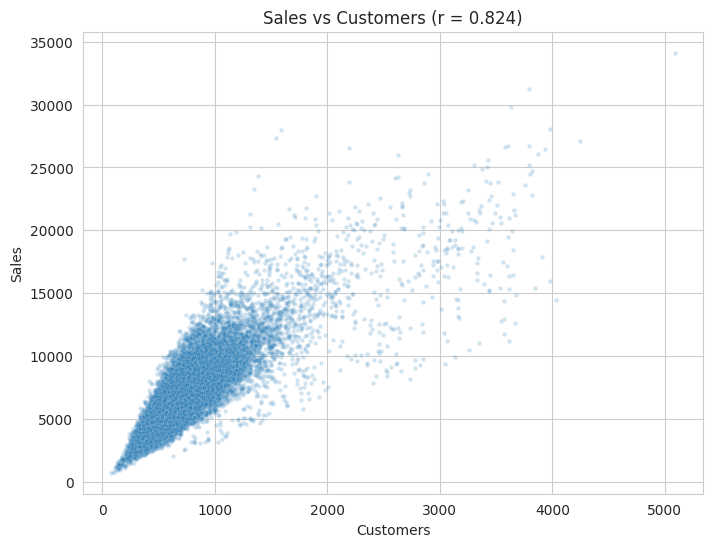

Correlation coefficient: 0.824


In [15]:

corr = open_data[['Sales', 'Customers']].corr().iloc[0, 1]
logger.info(f'Sales-Customers correlation: {corr:.3f}')

plt.figure(figsize=(8, 6))
sample_plot = open_data.sample(20000, random_state=42)
sns.scatterplot(data=sample_plot, x='Customers', y='Sales', alpha=0.2, s=10)
plt.title(f'Sales vs Customers (r = {corr:.3f})')
plt.show()

print(f'Correlation coefficient: {corr:.3f}')


**Insight:** Sales and Customers are strongly positively correlated (as expected — more foot traffic drives more revenue), but the relationship isn't perfectly linear: average basket size (Sales/Customer) varies by promo, store type and assortment, which we explore next.

### 6.5 How does Promo affect Sales and Customers?

             Sales   Customers  SalesPerCustomer
Promo                                           
0      5929.826183  696.906080          8.508788
1      8228.739731  844.481433          9.744133


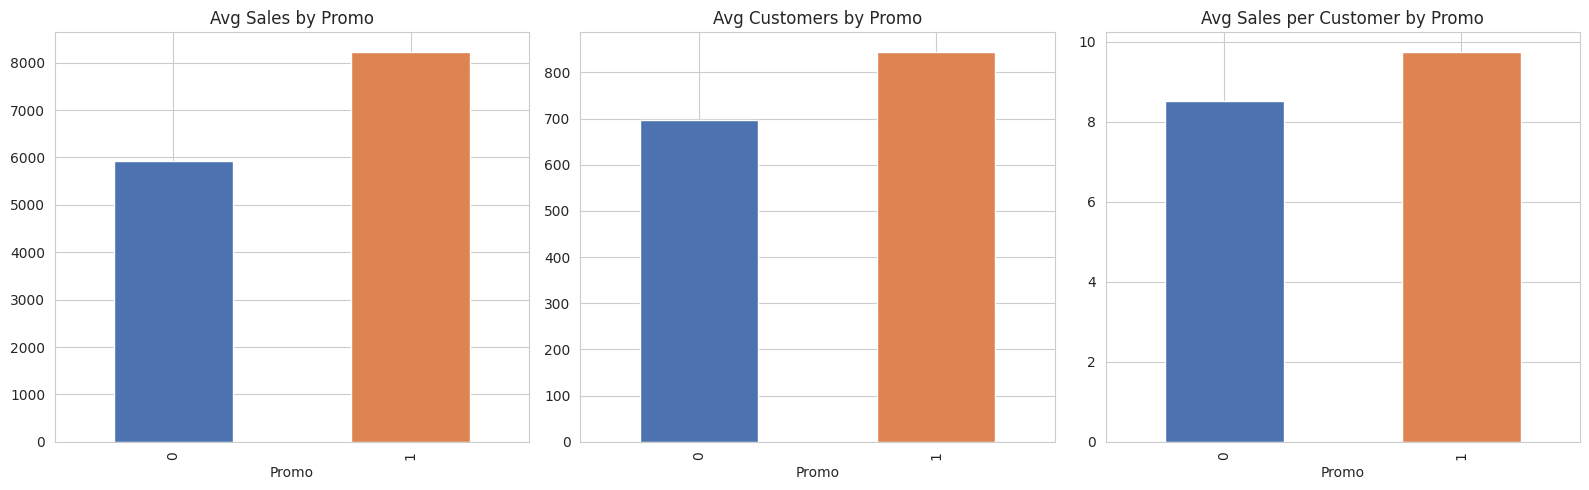

In [16]:

promo_compare = open_data.groupby('Promo')[['Sales', 'Customers']].mean()
promo_compare['SalesPerCustomer'] = promo_compare['Sales'] / promo_compare['Customers']
print(promo_compare)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
promo_compare['Sales'].plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Avg Sales by Promo')
promo_compare['Customers'].plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Avg Customers by Promo')
promo_compare['SalesPerCustomer'].plot(kind='bar', ax=axes[2], color=['#4C72B0', '#DD8452'])
axes[2].set_title('Avg Sales per Customer by Promo')
plt.tight_layout()
plt.show()


**Insight:** Promo days show higher average Sales *and* higher average Customers than non-promo days. If Sales-per-Customer is also higher on promo days, that means promos aren't just discounting existing purchases — they're driving genuinely higher basket sizes, not only attracting more foot traffic.

### 6.6 Which stores benefit most from promos? (candidates for expanded promo deployment)

Top 10 stores by promo sales uplift %:


,NoPromo,Promo,UpliftPct
Store,,,
198,1753.461538,4294.725212,144.928396
607,2551.573427,5542.971671,117.237396
543,1868.129930,3926.065714,110.160206
575,3614.405172,7586.112727,109.885510
693,4577.874710,9107.817143,98.952958
271,5452.700935,10746.485795,97.085553
552,5412.452436,10565.745714,95.211798
96,3638.345794,7047.616477,93.703866
635,4159.048951,8048.373219,93.514751



Bottom 10 stores by promo sales uplift %:


,NoPromo,Promo,UpliftPct
Store,,,
1075,11170.074246,11870.376771,6.269453
676,7529.674256,7947.112392,5.543907
760,7458.172897,7859.343840,5.378944
444,11917.105140,12521.787966,5.074075
353,5559.618467,5799.303371,4.311175
553,6928.909091,7173.818966,3.534609
827,12587.897674,12995.518414,3.238196
948,6865.652705,7071.454802,2.997561
262,20549.637457,20991.536111,2.150396


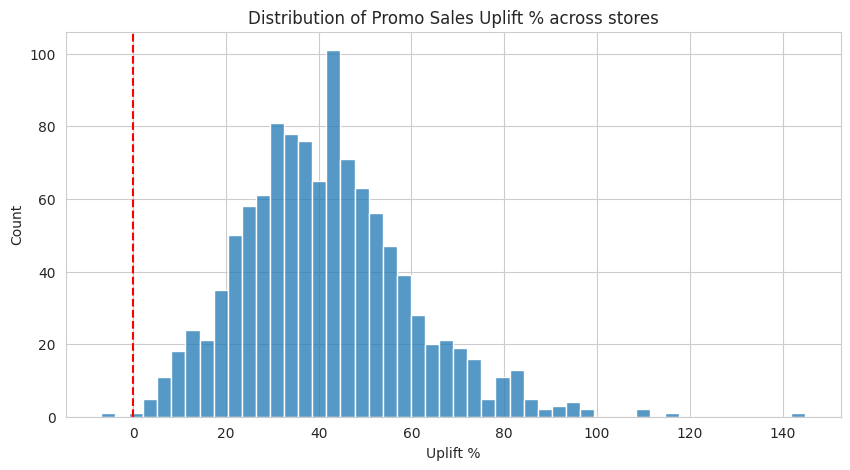

In [17]:

store_promo_uplift = open_data.groupby(['Store', 'Promo'])['Sales'].mean().unstack()
store_promo_uplift.columns = ['NoPromo', 'Promo']
store_promo_uplift['UpliftPct'] = (store_promo_uplift['Promo'] - store_promo_uplift['NoPromo']) / store_promo_uplift['NoPromo'] * 100
store_promo_uplift = store_promo_uplift.dropna().sort_values('UpliftPct', ascending=False)

print('Top 10 stores by promo sales uplift %:')
display(store_promo_uplift.head(10))

print('\nBottom 10 stores by promo sales uplift %:')
display(store_promo_uplift.tail(10))

plt.figure(figsize=(10, 5))
sns.histplot(store_promo_uplift['UpliftPct'], bins=50)
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Promo Sales Uplift % across stores')
plt.xlabel('Uplift %')
plt.show()


**Insight:** Promo uplift varies widely by store. Stores in the right tail (highest uplift %) are the best candidates for expanded/targeted promo deployment; stores with near-zero or negative uplift may need a different promotional strategy or none at all.

### 6.7 Store open/close trends

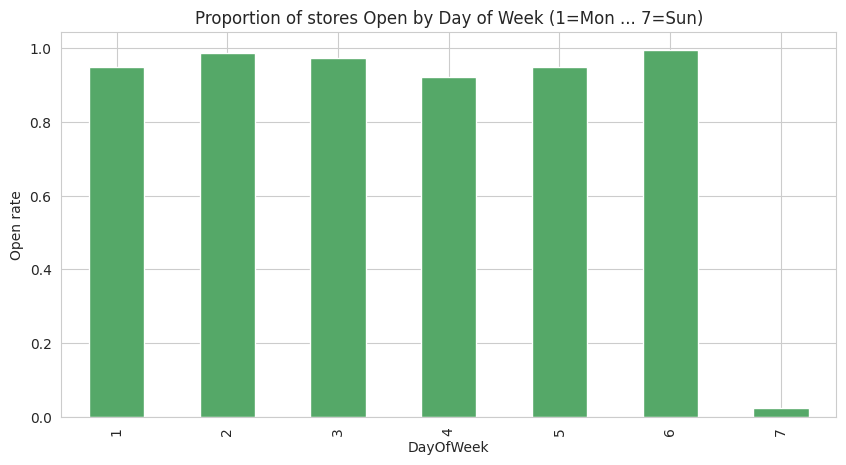

DayOfWeek
1    0.950458
2    0.988308
3    0.974398
4    0.923190
5    0.950596
6    0.995357
7    0.024826
Name: Open, dtype: float64


In [18]:

open_rate = train_merged.groupby('DayOfWeek')['Open'].mean()
open_rate.plot(kind='bar', color='#55A868')
plt.title('Proportion of stores Open by Day of Week (1=Mon ... 7=Sun)')
plt.ylabel('Open rate')
plt.show()

print(open_rate)


**Insight:** Most stores are open Monday–Saturday with a sharp drop in the open-rate on Sundays (day 7), consistent with typical German retail closing laws.

### 6.8 Stores open on all weekdays: does it help weekend sales?

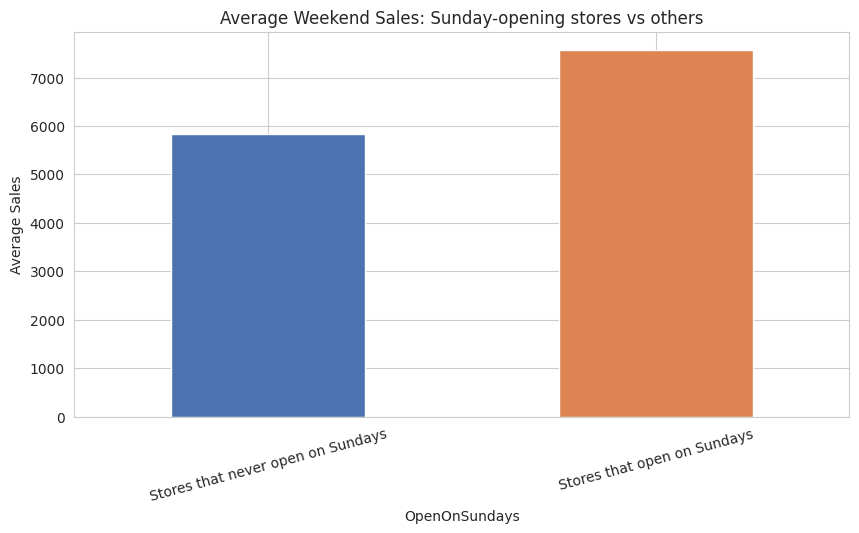

OpenOnSundays
Stores that never open on Sundays    5839.335970
Stores that open on Sundays          7564.956483
Name: Sales, dtype: float64


In [19]:

open_data['IsWeekend'] = open_data['DayOfWeek'].isin([6, 7]).astype(int)

# Stores that are ever open on Sunday
sunday_open_stores = train_merged[(train_merged['DayOfWeek'] == 7) & (train_merged['Open'] == 1)]['Store'].unique()
train_merged['OpenOnSundays'] = train_merged['Store'].isin(sunday_open_stores)

weekend_sales = train_merged[(train_merged['Open'] == 1) & (train_merged['DayOfWeek'].isin([6, 7]))]
comparison = weekend_sales.groupby('OpenOnSundays')['Sales'].mean()
comparison.index = comparison.index.map({True: 'Stores that open on Sundays', False: 'Stores that never open on Sundays'})
comparison.plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Average Weekend Sales: Sunday-opening stores vs others')
plt.ylabel('Average Sales')
plt.xticks(rotation=15)
plt.show()

print(comparison)


**Insight:** Stores that stay open on Sundays tend to show higher average weekend sales overall — being open captures demand that would otherwise be lost, rather than simply reallocating Saturday sales to Sunday.

### 6.9 Does Assortment type affect Sales?

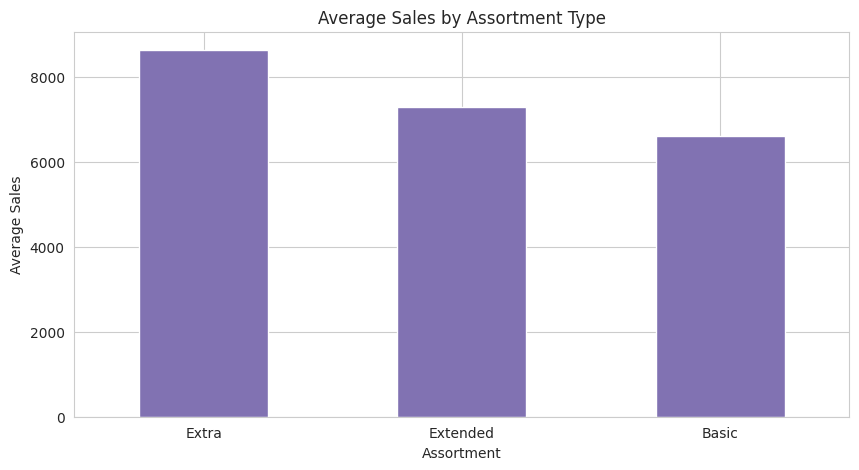

Assortment
Extra       8642.503594
Extended    7300.843547
Basic       6621.523057
Name: Sales, dtype: float64

Store count by assortment:
Assortment
a    593
c    513
b      9
Name: count, dtype: int64


In [20]:

assortment_sales = train_merged[train_merged['Open'] == 1].groupby('Assortment')['Sales'].mean().sort_values(ascending=False)
assortment_labels = {'a': 'Basic', 'b': 'Extra', 'c': 'Extended'}
assortment_sales.index = assortment_sales.index.map(assortment_labels)

assortment_sales.plot(kind='bar', color='#8172B2')
plt.title('Average Sales by Assortment Type')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.show()

print(assortment_sales)
print()
print('Store count by assortment:')
print(store['Assortment'].value_counts())


**Insight:** 'Extra' assortment stores tend to show the highest average sales, though they're also the rarest — so this must be read alongside store count, not as a simple causal signal.

### 6.10 Does competition distance affect Sales?

2026-08-14 06:36:35,389 | INFO | Sales vs CompetitionDistance correlation: -0.042


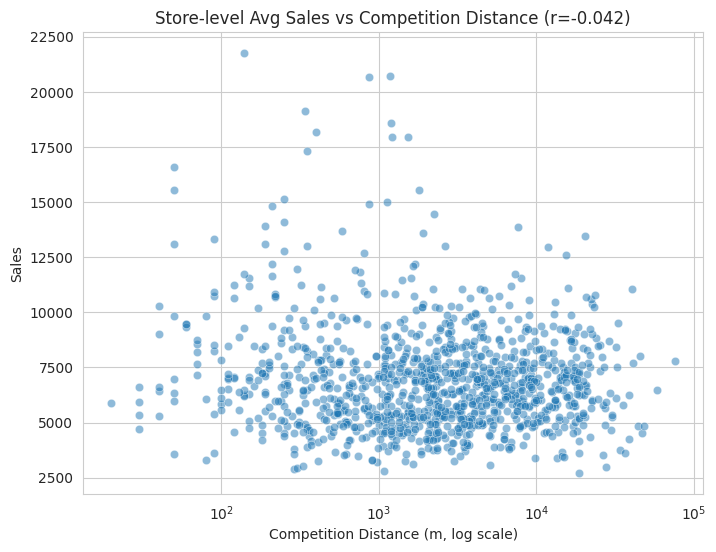

Correlation: -0.042


In [21]:

merged_open = train_merged[train_merged['Open'] == 1]
store_avg_sales = merged_open.groupby('Store').agg({'Sales': 'mean', 'CompetitionDistance': 'first', 'StoreType': 'first'}).dropna()

corr_dist = store_avg_sales[['Sales', 'CompetitionDistance']].corr().iloc[0, 1]
logger.info(f'Sales vs CompetitionDistance correlation: {corr_dist:.3f}')

plt.figure(figsize=(8, 6))
sns.scatterplot(data=store_avg_sales, x='CompetitionDistance', y='Sales', alpha=0.5)
plt.xscale('log')
plt.title(f'Store-level Avg Sales vs Competition Distance (r={corr_dist:.3f})')
plt.xlabel('Competition Distance (m, log scale)')
plt.show()

print(f'Correlation: {corr_dist:.3f}')


**Insight:** The correlation between competition distance and average sales is typically weak/counter-intuitive at the raw level — nearby competitors are often in busy city-center locations where foot traffic (and therefore sales) is high for *everyone*, competitor or not. This is exactly the city-centre confound the brief calls out: distance alone isn't a reliable predictor without controlling for store location/type.

### 6.11 Impact of a competitor opening/reopening (stores with NA→value CompetitionDistance over time)

2026-08-14 06:36:35,690 | INFO | Stores with a competitor opening mid-observation-window: 188


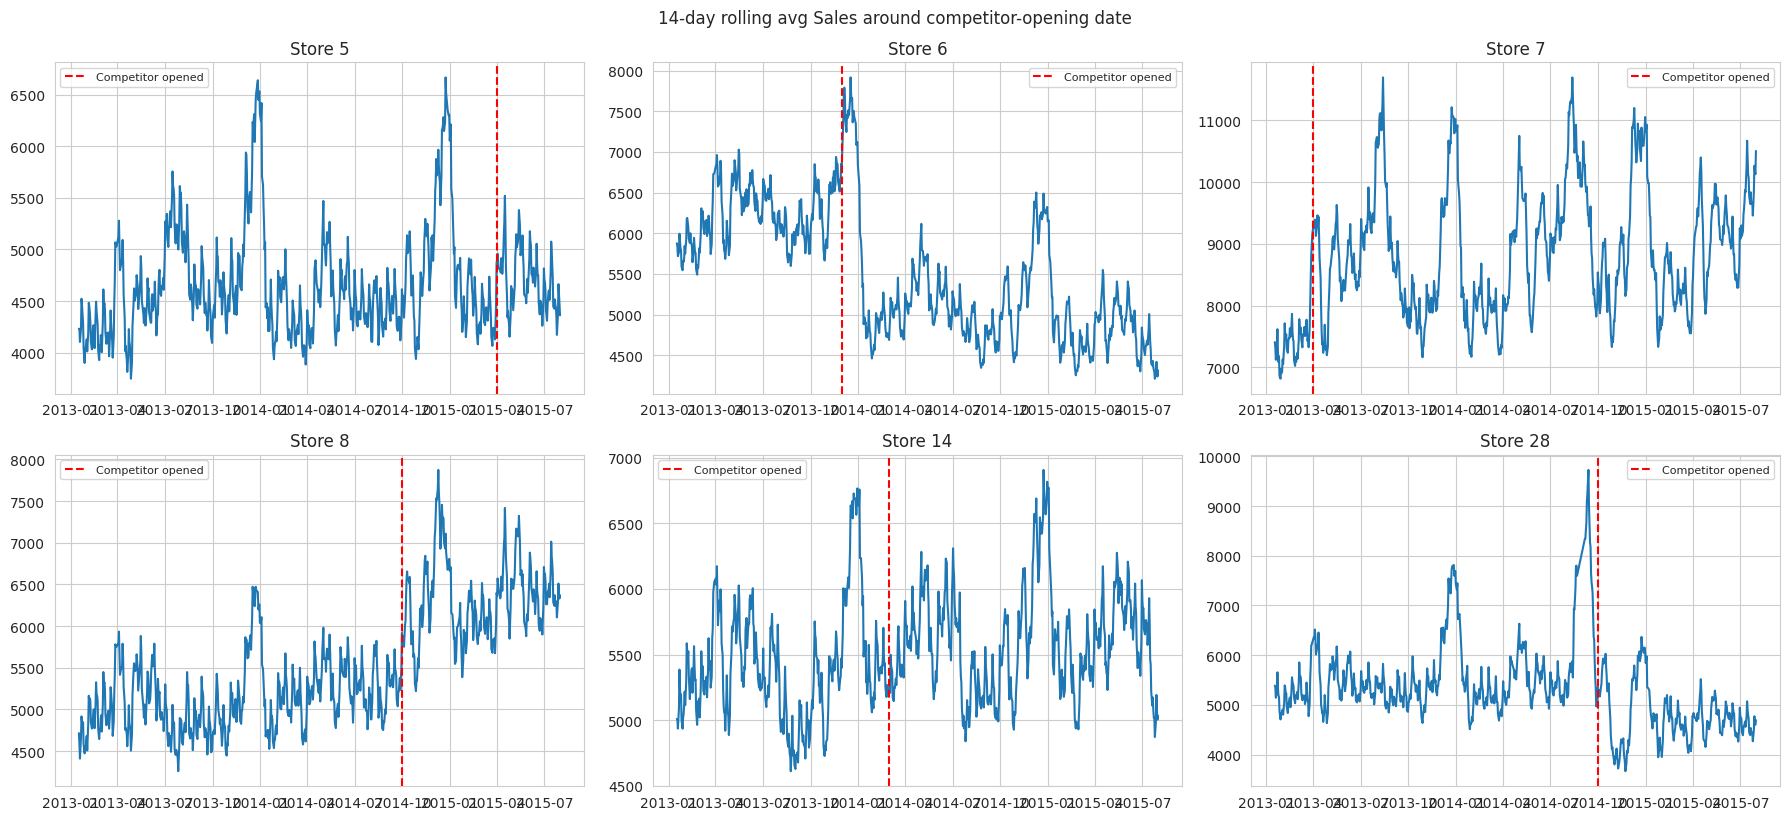

In [22]:

# Identify stores where competition opened partway through the observed period
has_competition_date = store[(store['CompetitionOpenSinceYear'] > 0) & (store['CompetitionOpenSinceMonth'] > 0)].copy()
has_competition_date['CompetitionOpenDate'] = pd.to_datetime(
    has_competition_date['CompetitionOpenSinceYear'].astype(str) + '-' +
    has_competition_date['CompetitionOpenSinceMonth'].astype(str) + '-01'
)

# Restrict to competitor-open dates that fall inside our train date range, so we can see before/after
train_min, train_max = train_merged['Date'].min(), train_merged['Date'].max()
mid_window_stores = has_competition_date[
    (has_competition_date['CompetitionOpenDate'] > train_min) &
    (has_competition_date['CompetitionOpenDate'] < train_max)
]
logger.info(f'Stores with a competitor opening mid-observation-window: {len(mid_window_stores)}')

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()
for i, sid in enumerate(mid_window_stores['Store'].head(6)):
    s = train_merged[(train_merged['Store'] == sid) & (train_merged['Open'] == 1)].sort_values('Date')
    comp_date = mid_window_stores[mid_window_stores['Store'] == sid]['CompetitionOpenDate'].iloc[0]
    axes[i].plot(s['Date'], s['Sales'].rolling(14).mean())
    axes[i].axvline(comp_date, color='red', linestyle='--', label='Competitor opened')
    axes[i].set_title(f'Store {sid}')
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.suptitle('14-day rolling avg Sales around competitor-opening date', y=1.02)
plt.show()


**Insight:** For stores where a nearby competitor opened partway through the observed period, the 14-day rolling sales trend around the red line shows whether the new competitor caused a visible, lasting dip — in practice this varies store to store, again suggesting distance/competition effects are highly local rather than universal.

## 7. Summary of Key Findings

(Fill in concrete numbers/observations from the outputs above when writing the 3-5 slide interim presentation.)

- Promo distribution across train/test
- Holiday sales pattern (spike before, drop during, partial rebound after)
- Seasonal peak around December
- Strong Sales-Customer correlation
- Promo increases both traffic and sales-per-customer
- Promo uplift is store-specific — targeting opportunity
- Sunday-opening stores capture extra weekend demand
- Assortment 'Extra' stores over-index on sales
- Competition distance effect is weak/confounded by location
- Competitor openings can dent sales, but effect is store-specific